In [5]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# 한글 폰트 설정 (윈도우)
plt.rcParams["font.family"] = "Malgun Gothic"   # 맑은 고딕
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지

torch.manual_seed(42)
np.random.seed(42)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(torch.__version__)
print(device)

2.11.0+cu128
cuda


In [6]:
base_dir = "./chest_xray/chest_xray"
if not os.path.isdir(base_dir):
    print("데이터없음")
else:
    for split in ["train", "test"]:
        for cls in ['NORMAL', 'PNEUMONIA']:
            p = os.path.join(base_dir, split, cls)
            print(f"{split}/{cls:10s}: {len(os.listdir(p)):5d}장")

train/NORMAL    :  1341장
train/PNEUMONIA :  3875장
test/NORMAL    :   242장
test/PNEUMONIA :   398장


In [7]:
batch_size = 32
image_size = 224
learning_rate = 5e-4
epochs = 2
class_labels = ['NORMAL', 'PNEUMONIA']


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomAffine(degrees = 0, translate = (0.1, 0.1), scale = (0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  
])

eval_tf = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [9]:
train_full = datasets.ImageFolder(os.path.join(base_dir, "train"), transform = train_tf)
val_full = datasets.ImageFolder(os.path.join(base_dir, "train"), transform = eval_tf)
test_set = datasets.ImageFolder(os.path.join(base_dir, "test"), transform = eval_tf)

print(train_full.class_to_idx)


{'NORMAL': 0, 'PNEUMONIA': 1}


In [10]:
n_total = len(train_full)
n_val = int(n_total * 0.2)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator = g).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_set = Subset(train_full, train_idx)
val_set = Subset(val_full, val_idx)

train_loader = DataLoader(
    train_set,
    batch_size = batch_size,
    shuffle = True
)
val_loader = DataLoader(
    val_set, 
    batch_size = batch_size, 
    shuffle = False
)
test_loader = DataLoader(
    test_set,
    batch_size = batch_size,
    shuffle = False
)

print(len(train_set), len(val_set), len(test_set))


4173 1043 640


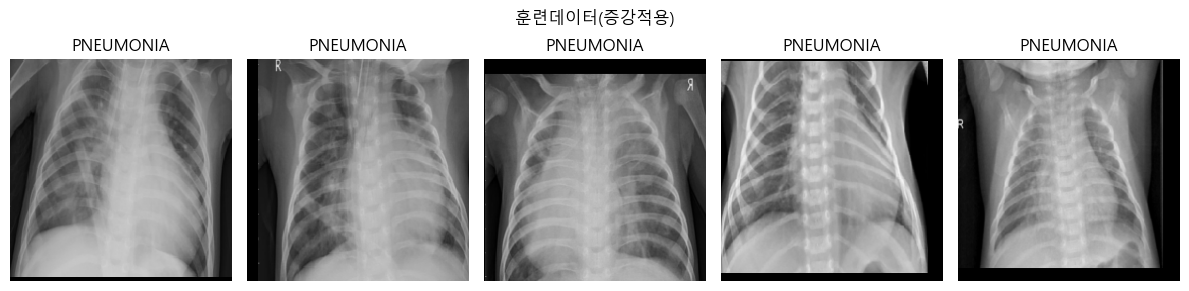

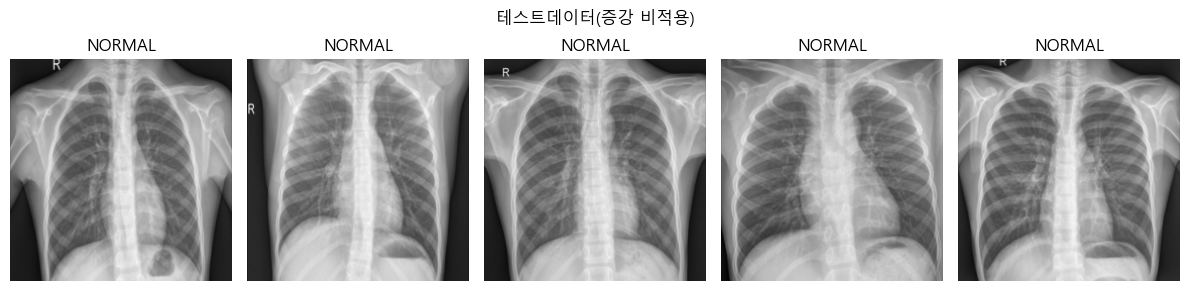

In [11]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1)

def show_images(loader, num_images = 5, title = ""):
    images, labels = next(iter(loader))
    plt.figure(figsize = (12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(denormalize(images[i]).permute(1, 2, 0).numpy())
        plt.title(class_labels[int(labels[i])])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(train_loader, title = "훈련데이터(증강적용)")
show_images(test_loader, title = "테스트데이터(증강 비적용)")


In [12]:
import timm

class XrayNet(nn.Module):
    def __init__(self, pretrained = True):
        super().__init__()
        self.backbone = timm.create_model("resnetv2_50", pretrained = pretrained, num_classes = 0, global_pool = "avg")
        n_feat = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(n_feat, 128),
            nn.ReLU(inplace = True),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.head(self.backbone(x))

model = XrayNet(pretrained = True)
with torch.no_grad():
    out = model(torch.zeros(2, 3, image_size, image_size))
print(f"출력 모양: {tuple(out.shape)}")
print(f"파라미터: {sum(p.numel() for p in model.parameters()):,}")

출력 모양: (2, 1)
파라미터: 23,762,753


In [13]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score, roc_auc_score, confusion_matrix)

@torch.no_grad() # 이거나오면 eval 쓰기
def evaluation(model, loader, criterion = None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb,yb = xb.to(device), yb.float().to(device)
        logits = model(xb).squeeze(1)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = (probs > 0.5).astype(int)

    return {
        "loss" : (sum(losses)) / len(trues) if criterion is not None else None,
        "accuracy" : accuracy_score(trues, preds),
        "recall" : recall_score(trues, preds, zero_division = 0),
        "precision" : precision_score(trues, preds, zero_division = 0),
        "auc" : roc_auc_score(trues, probs) if len(set(trues)) > 1 else float("nan"),
        "probs" : probs,
        "trues" : trues,
        "preds" : preds,
    }

def train_model(model, train_loader, val_loader, epochs = 20, lr = 5e-4, pos_weight = None, ckpt_path = "checkpoint.pt", label = "model"):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode = "min",
        factor = 0.1,
        patience = 2,
        min_lr = 1e-7
    )
    history = {k: [] for k in ["loss", "val_loss", "accuracy", "val_accuracy", "val_recall", "val_precision", "val_auc"]}

    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.float().to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * len(yb)
            run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n

        m = evaluation(model, val_loader, criterion)

        history["loss"].append(tr_loss)
        history["accuracy"].append(tr_acc)
        history["val_loss"].append(m["loss"])
        history["val_accuracy"].append(m["accuracy"])
        history["val_recall"].append(m["recall"])
        history["val_precision"].append(m["precision"])
        history["val_auc"].append(m["auc"])

        star = ""
        if m["loss"] < best_val:
            best_val = m["loss"]
            torch.save(model.state_dict(), ckpt_path)
            star = "저장"

        print(f"[{label}] {epoch:2d} / {epochs}")
        print(f"loss {tr_loss:.4f} val_loss {m['loss']:.4f}")
        print(f"val_acc {m['accuracy']:.4f} val_auc {m['auc']:.4f}")
        print(f"lr {optimizer.param_groups[0]['lr']:.1e}")
        print(f"{time.time() -t0:.0f}) {star}")
    print(f"best val_loss = {best_val:4f} {ckpt_path}")
    return history

In [14]:
model = XrayNet(pretrained = True)
history = train_model(model, train_loader, val_loader, epochs = epochs, lr = learning_rate)

[model]  1 / 2
loss 0.2778 val_loss 0.1024
val_acc 0.9597 val_auc 0.9910
lr 5.0e-04
89) 저장
[model]  2 / 2
loss 0.1179 val_loss 0.1599
val_acc 0.9406 val_auc 0.9950
lr 5.0e-04
84) 
best val_loss = 0.102364 checkpoint.pt


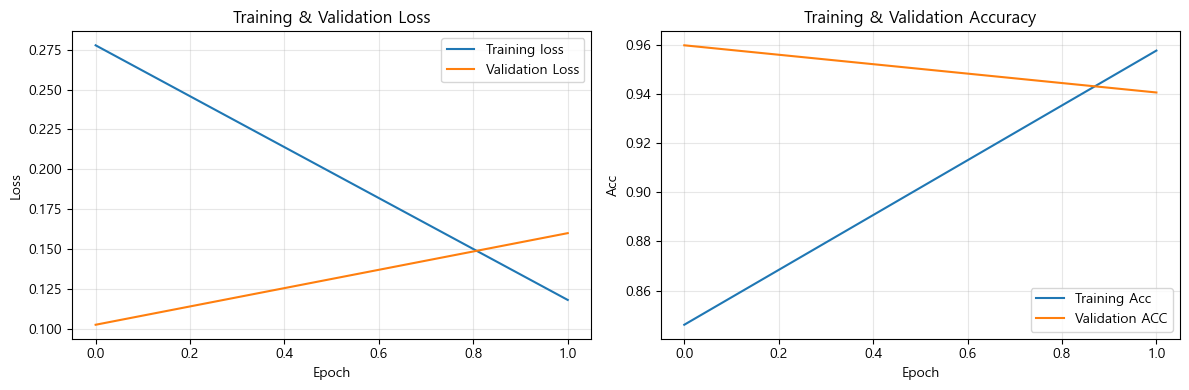

In [15]:
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.plot(history["loss"], label = "Training loss")
plt.plot(history["val_loss"], label = "Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(history["accuracy"], label = "Training Acc")
plt.plot(history["val_accuracy"], label = "Validation ACC")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()


In [16]:
best = XrayNet(pretrained = False).to(device)
best.load_state_dict(torch.load("checkpoint.pt", map_location = device))
m = evaluation(best, test_loader)
print(m["accuracy"], m["auc"])

0.8421875 0.9561962706092446


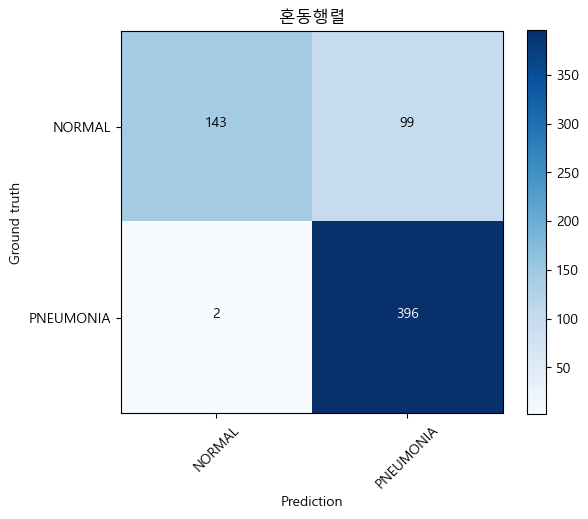

In [17]:
import itertools

def plot_confusion_matrix(cm, classes, normalize = False, title = "혼동 행렬", cmap = plt.cm.Blues):
    plt.imshow(cm, interpolation = "nearest", cmap = cmap)
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation = 45)
    plt.yticks(ticks, classes)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i,j], horizontalalignment = "center", color = "white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel("Ground truth")
    plt.xlabel("Prediction")

cm = confusion_matrix(m["trues"],m["preds"])
plt.figure(figsize = (6, 5))
plot_confusion_matrix(cm, classes = class_labels, title = "혼동행렬")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(m["trues"], m["preds"], target_names = class_labels))

              precision    recall  f1-score   support

      NORMAL       0.99      0.59      0.74       242
   PNEUMONIA       0.80      0.99      0.89       398

    accuracy                           0.84       640
   macro avg       0.89      0.79      0.81       640
weighted avg       0.87      0.84      0.83       640



In [ ]:
from sklearn.metrics import balanced_accuracy_score, average_precision_score

def medical_metrics(trues, preds, probs):
    tn, fp, fn, tp = confusion_matrix(trues, preds).ravel()

    return{
        "정확도" : (tp + tn) / (tp + tn + fp + fn),
        "균형 정확도" : balanced_accuracy_score(trues, preds),
        "민감도" : tp / (tp + fn) if (tp + fn) else 0.0, 
        "특이도" : tn / (tn + fp) if (tn + fp) else 0.0,
        "정밀도" : tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV" : tn / (tn + fn) if (tn + fn) else 0.0,
        "ROC_AUC" : roc_auc_score(trues, probs),
        "PR_AUC" : average_precision_score(trues, probs),
        "_counts" : (tn, fp, fn, tp)
    }

res = medical_metrics(m["trues"], m["preds"], m['probs'])
tn, fp, fn, tp = res.pop("_counts")

n_norm = int((m["trues"] == 0).sum())
n_pneu = int((m["trues"] == 1).sum())

print(f"정상: {n_norm}, 폐렴: {n_pneu}")
print(f"{n_pneu / (n_norm + n_pneu):.1%}") # 

for k, v in res.items():
    mark = "중요" if k == "민감도" else ""
    print(f"{k:12s} : {v:.4f}{mark}")
print(f"놓친 폐렴환자 (FN) : {fn}명")
print(f"정상->폐렴 (FP) : {fp}명")

정상: 242, 폐렴: 398
62.2%
정확도          : 0.8422
균형 정확도       : 0.7929
민감도          : 0.9950중요
특이도          : 0.5909
정밀도          : 0.8000
NPV          : 0.9862
ROC_AUC      : 0.9562
PR_AUC       : 0.9669
놓친 폐렴환자 (FN) : 2명
정상->폐렴 (FP) : 99명


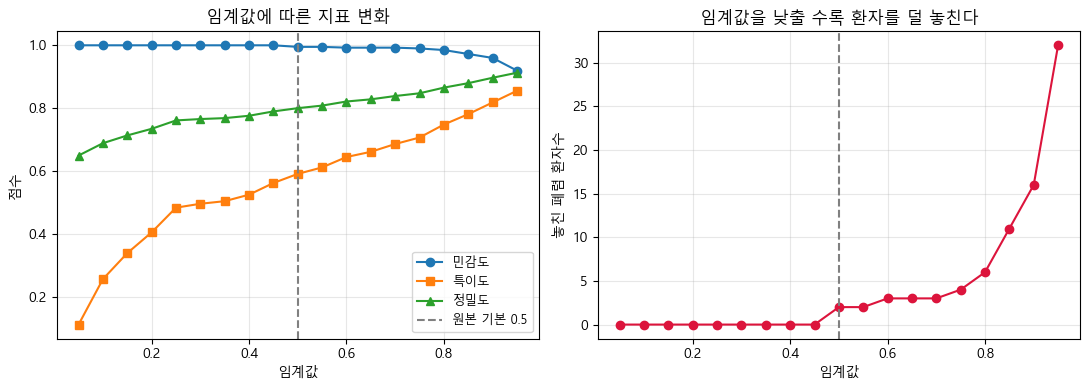

민감도 99% 이상을 만족하는 임계값 중 특이도가 제일 높은 지점
임계값 0.70 -> 민감도 0.9925
특이값 0.6860 놓친 환자 3


In [23]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []
for t in thresholds:
    p = (m["probs"] > t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(m["trues"], p, labels = [0, 1]).ravel()
    rows.append({
        "threshold" : t,
        "sens" : tp_ / (tp_ + fn_) if (tp_ + fn_) else 0.0,
        "spec" : tn_ / (tn_ + fp_) if (tn_ + fp_) else 0.0,
        "prec" : tp_ / (tp_ + fp_) if (tp_ + fp_) else 0.0,
        "fn" : fn_
    })
plt.figure(figsize = (11,4))
plt.subplot(1,2,1)
plt.plot(thresholds, [r["sens"] for r in rows], "o-", label="민감도")
plt.plot(thresholds, [r["spec"] for r in rows], "s-", label="특이도")   # spec
plt.plot(thresholds, [r["prec"] for r in rows], "^-", label="정밀도")   # prec
plt.axvline(0.5, color = "gray", ls = "--", label = "원본 기본 0.5")
plt.xlabel("임계값")
plt.ylabel("점수")
plt.legend(fontsize = 9)
plt.grid(alpha = 0.3)
plt.title("임계값에 따른 지표 변화")

plt.subplot(1,2,2)
plt.plot(thresholds, [r["fn"] for r in rows], "o-", color = "crimson")
plt.axvline(0.5, color = "gray", ls = "--")
plt.xlabel("임계값")
plt.ylabel("놓친 폐렴 환자수")
plt.title("임계값을 낮출 수록 환자를 덜 놓친다")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

TARGET = 0.99
candidates = [r for r in rows if r["sens"] >= TARGET]
if candidates:
    chosen = max(candidates, key = lambda r: r["spec"])
    print(f"민감도 {TARGET:.0%} 이상을 만족하는 임계값 중 특이도가 제일 높은 지점")
    print(f"임계값 {chosen['threshold']:.2f} -> 민감도 {chosen['sens']:.4f}")
    print(f"특이값 {chosen['spec']:.4f} 놓친 환자 {chosen['fn']}")
else:
    print(f"민감도 {TARGET:.0%}를 만족하는 임계값이 없음.")


# 에폭 2번돌리더라도 임계값을 조정하면 좋은 효과를 낼수있음

In [26]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.acts = None
        self.grads = None
        self.handles = [
            target_layer.register_forward_hook(self._save_acts),
            target_layer.register_full_backward_hook(self._save_grads)
        ]

    def _save_acts(self, module, inp, out):
        self.acts = out.detach()
    def _save_grads(self, module, grad_in, grad_out):
        self.grads = grad_out[0].detach()
    def __call__(self, x):
        self.model.zero_grad()
        logit = self.model(x).squeeze()
        logit.backward()

        weights = self.grads.mean(dim = (2, 3), keepdim = True)
        heat = (weights * self.acts).sum(dim = 1).squeeze(0)
        heat = torch.relu(heat)
        if heat.max() > 0:
            heat = heat / heat.max()
        return heat.cpu().numpy()
    def remove(self):
        for h in self.handles:
            h.remove()

def overlay_heatmap(heat, img01, alpha = 0.4):
    import torch.nn.functional as F
    h = torch.from_numpy(heat)[None, None]
    h = F.interpolate(h, size = img01.shape[:2], mode = "bilinear", align_corners = False)[0,0].numpy()
    jet = plt.get_cmap("jet")(h)[:, :, :3]
    return np.clip(img01 * (1-alpha) + jet * alpha, 0, 1)


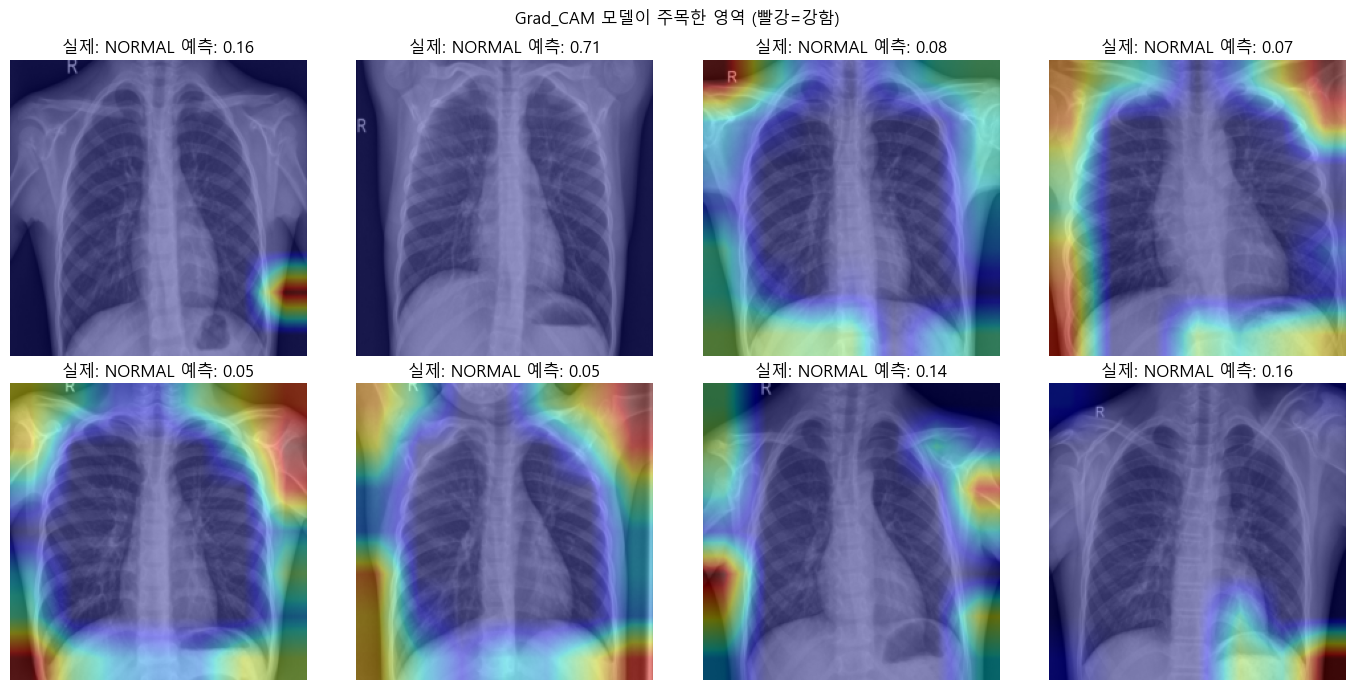

In [27]:
# 캠 시각화

target_layer = best.backbone.stages[-1]
cam = GradCAM(best, target_layer)

fig, ax = plt.subplots(2, 4, figsize = (14, 7))
it = iter(test_loader)
xb, yb = next(it)

for k in range(8):
    i, j = divmod(k, 4)
    x = xb[k:k+1].to(device)
    lab = int(yb[k])

    heat = cam(x)
    img01 = denormalize(xb[k]).permute(1, 2, 0).numpy()

    with torch.no_grad():
        p = torch.sigmoid(best(x)).item()

    ax[i, j].imshow(overlay_heatmap(heat, img01))
    ax[i, j].set_title(f"실제: {class_labels[lab]} 예측: {p:.2f}")
    ax[i, j].axis("off")

cam.remove()
plt.suptitle("Grad_CAM 모델이 주목한 영역 (빨강=강함)")
plt.tight_layout()
plt.show()